In [12]:
# CELL 1: Setup and Upload zip file
# =======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from google.colab import files
from datetime import datetime, timedelta

print("=" * 60)
print("🏏 MEN'S T20 CRICKET ANALYSIS - LAST 7 DAYS")
print("=" * 60)

# Upload your zip file
print("\n📁 Please upload your zip file: recently_added_7_male_csv2")
uploaded = files.upload()

# Get the filename
zip_filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {zip_filename}")
print(f"File size: {len(uploaded[zip_filename]) / (1024*1024):.2f} MB")

# Extract files
print("\n📂 Extracting files...")
extract_folder = 'mens_t20_recent'
if not os.path.exists(extract_folder):
    os.makedirs(extract_folder)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
    all_files = os.listdir(extract_folder)
    print(f"✅ Extracted {len(all_files)} files")

# Separate ball-by-ball files (ignore info files for now)
ball_files = [os.path.join(extract_folder, f) for f in all_files
              if f.endswith('.csv') and not f.endswith('_info.csv')]
info_files = [os.path.join(extract_folder, f) for f in all_files
              if f.endswith('_info.csv')]

print(f"\n📊 Found {len(ball_files)} ball-by-ball files")
print(f"📋 Found {len(info_files)} info files")

🏏 MEN'S T20 CRICKET ANALYSIS - LAST 7 DAYS

📁 Please upload your zip file: recently_added_7_male_csv2


Saving recently_added_7_male_csv2.zip to recently_added_7_male_csv2.zip
✅ Uploaded: recently_added_7_male_csv2.zip
File size: 0.16 MB

📂 Extracting files...
✅ Extracted 61 files

📊 Found 30 ball-by-ball files
📋 Found 30 info files


In [13]:
# CELL 2: Load all ball-by-ball files
# ====================================

print("\n🔄 Loading ball-by-ball data...")

ball_dfs = []
for i, file in enumerate(ball_files):
    try:
        df = pd.read_csv(file)
        # Extract match_id from filename
        match_id = os.path.basename(file).replace('.csv', '')
        df['match_id'] = match_id
        ball_dfs.append(df)

        if (i + 1) % 10 == 0:
            print(f"   Loaded {i + 1}/{len(ball_files)} files")

    except Exception as e:
        print(f"   ⚠️ Error loading {os.path.basename(file)}: {e}")

# Combine all data
if ball_dfs:
    df_balls = pd.concat(ball_dfs, ignore_index=True)
    print(f"\n✅ SUCCESS!")
    print(f"   Total matches: {df_balls['match_id'].nunique()}")
    print(f"   Total balls: {len(df_balls):,}")
    print(f"   Columns: {len(df_balls.columns)}")
else:
    print("❌ No data loaded!")


🔄 Loading ball-by-ball data...
   Loaded 10/30 files
   Loaded 20/30 files
   Loaded 30/30 files

✅ SUCCESS!
   Total matches: 30
   Total balls: 19,642
   Columns: 22


In [14]:
# CELL 3: Process and clean the data
# ===================================

print("\n🔄 Processing data...")

# Convert ball to over number
df_balls['over_number'] = df_balls['ball'].astype(float).astype(int)

# Add phase based on over number
def get_phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle'
    else:
        return 'Death'

df_balls['phase'] = df_balls['over_number'].apply(get_phase)

# Add wicket flag (1 if wicket fell, 0 if not)
df_balls['wicket'] = df_balls['wicket_type'].notna().astype(int)

# Add total runs (runs off bat + extras)
df_balls['total_runs'] = df_balls['runs_off_bat'] + df_balls['extras'].fillna(0)

print("✅ Data processing complete!")
print(f"\n📊 Phase distribution:")
print(df_balls['phase'].value_counts())

# Show sample
print("\n👀 Sample of processed data:")
print(df_balls[['match_id', 'innings', 'over_number', 'phase', 'total_runs', 'wicket']].head(10))


🔄 Processing data...
✅ Data processing complete!

📊 Phase distribution:
phase
Death        12231
Middle        4056
Powerplay     3355
Name: count, dtype: int64

👀 Sample of processed data:
  match_id  innings  over_number      phase  total_runs  wicket
0  1499339        1            0  Powerplay           0       0
1  1499339        1            0  Powerplay           4       0
2  1499339        1            0  Powerplay           0       1
3  1499339        1            0  Powerplay           0       0
4  1499339        1            0  Powerplay           0       0
5  1499339        1            0  Powerplay           0       0
6  1499339        1            1  Powerplay           0       0
7  1499339        1            1  Powerplay           0       0
8  1499339        1            1  Powerplay           2       0
9  1499339        1            1  Powerplay           0       0


In [15]:
# CELL 4: Create over-by-over summary
# ====================================

print("\n🔄 Creating over statistics...")

# Group by match, innings, over
over_stats = df_balls.groupby(['match_id', 'innings', 'over_number', 'phase']).agg({
    'total_runs': 'sum',
    'wicket': 'sum',
    'runs_off_bat': 'sum',
    'extras': 'sum'
}).reset_index()

# Rename columns
over_stats.rename(columns={
    'total_runs': 'runs_in_over',
    'wicket': 'wickets_in_over'
}, inplace=True)

print(f"✅ Created over_stats with {len(over_stats)} overs")

# Show summary by phase
phase_summary = over_stats.groupby('phase').agg({
    'runs_in_over': ['count', 'mean', 'std']
}).round(2)

print("\n📊 Phase Summary:")
print(phase_summary)


🔄 Creating over statistics...
✅ Created over_stats with 3231 overs

📊 Phase Summary:
          runs_in_over            
                 count  mean   std
phase                             
Death             2028  3.85  3.41
Middle             664  4.82  3.79
Powerplay          539  5.13  4.25



📋 CREATING TABLE 1: Phase Statistics

📊 Table Data:
--------------------------------------------------------------------------------
Phase	Overs	Avg Runs	Std Dev	Min	Max	Wicket Rate
Powerplay	539	5.13	4.25	0	24	3.5%
Middle	664	4.82	3.79	0	24	3.9%
Death	2,028	3.85	3.41	0	24	2.6%


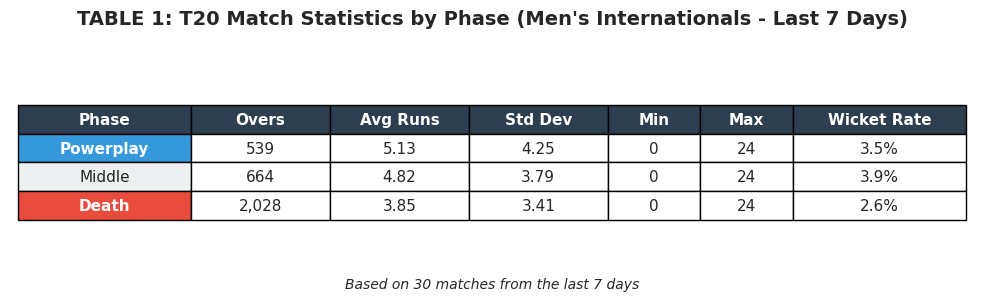

✅ Table saved as 'table1_phase_stats.png'


In [22]:
# CELL 5: TABLE 1 - Phase Statistics (FIXED VERSION)
# ===================================================

print("\n📋 CREATING TABLE 1: Phase Statistics")

# Calculate detailed statistics
phase_stats = over_stats.groupby('phase').agg({
    'runs_in_over': ['count', 'mean', 'std', 'min', 'max'],
    'wickets_in_over': 'mean'
}).round(2)

# Calculate wicket rate separately (to avoid MultiIndex issues)
wicket_rate = over_stats.groupby('phase')['wickets_in_over'].mean() * 100 / 6

# Prepare table data
table_data = []
for phase in ['Powerplay', 'Middle', 'Death']:
    if phase in phase_stats.index:
        row = [
            phase,
            f"{int(phase_stats.loc[phase, ('runs_in_over', 'count')]):,}",
            f"{phase_stats.loc[phase, ('runs_in_over', 'mean')]:.2f}",
            f"{phase_stats.loc[phase, ('runs_in_over', 'std')]:.2f}",
            f"{int(phase_stats.loc[phase, ('runs_in_over', 'min')])}",
            f"{int(phase_stats.loc[phase, ('runs_in_over', 'max')])}",
            f"{wicket_rate[phase]:.1f}%"
        ]
        table_data.append(row)

# Print the table data first (for verification)
print("\n📊 Table Data:")
print("-" * 80)
print("Phase\tOvers\tAvg Runs\tStd Dev\tMin\tMax\tWicket Rate")
for row in table_data:
    print("\t".join(row))

# Create a nice looking table
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=table_data,
                 colLabels=['Phase', 'Overs', 'Avg Runs', 'Std Dev', 'Min', 'Max', 'Wicket Rate'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.15, 0.12, 0.12, 0.12, 0.08, 0.08, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Style the table
for (i, j), cell in table.get_celld().items():
    if i == 0:  # Header
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(weight='bold', color='white')
    elif j == 0:  # Phase column
        if cell.get_text().get_text() == 'Powerplay':
            cell.set_facecolor('#3498db')
            cell.set_text_props(weight='bold', color='white')
        elif cell.get_text().get_text() == 'Death':
            cell.set_facecolor('#e74c3c')
            cell.set_text_props(weight='bold', color='white')
        else:
            cell.set_facecolor('#ecf0f1')

plt.title('TABLE 1: T20 Match Statistics by Phase (Men\'s Internationals - Last 7 Days)',
          fontsize=14, fontweight='bold', pad=20)

# Add footer
total_matches = df_balls['match_id'].nunique()
plt.figtext(0.5, 0.01, f'Based on {total_matches} matches from the last 7 days',
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('table1_phase_stats.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Table saved as 'table1_phase_stats.png'")

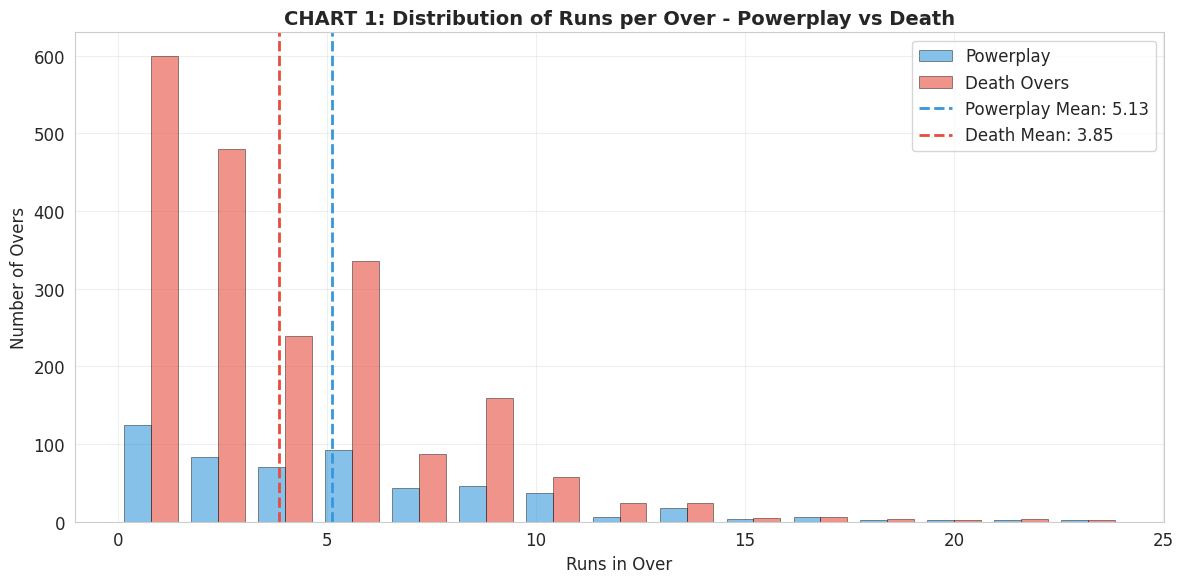

✅ Chart 1 saved as 'chart1_powerplay_vs_death.png'


In [23]:
# CELL 6: CHART 1 - Histogram Overlay
# ====================================

plt.figure(figsize=(12, 6))

# Separate data
powerplay_runs = over_stats[over_stats['phase']=='Powerplay']['runs_in_over']
death_runs = over_stats[over_stats['phase']=='Death']['runs_in_over']

# Create histogram
plt.hist([powerplay_runs, death_runs], bins=15,
         color=['#3498db', '#e74c3c'],
         alpha=0.6, label=['Powerplay', 'Death Overs'],
         edgecolor='black', linewidth=0.5)

plt.title('CHART 1: Distribution of Runs per Over - Powerplay vs Death',
          fontsize=14, fontweight='bold')
plt.xlabel('Runs in Over', fontsize=12)
plt.ylabel('Number of Overs', fontsize=12)

# Add vertical lines for means
plt.axvline(powerplay_runs.mean(), color='#3498db', linestyle='--',
            linewidth=2, label=f"Powerplay Mean: {powerplay_runs.mean():.2f}")
plt.axvline(death_runs.mean(), color='#e74c3c', linestyle='--',
            linewidth=2, label=f"Death Mean: {death_runs.mean():.2f}")

plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_powerplay_vs_death.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved as 'chart1_powerplay_vs_death.png'")

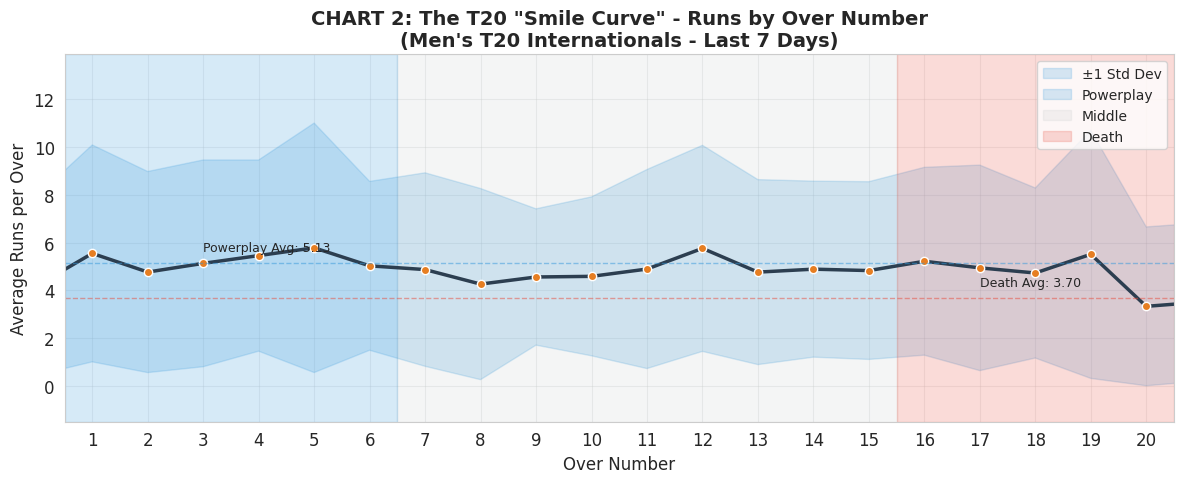

✅ Chart 2 saved as 'chart2_smile_curve.png'


In [24]:
# CELL 7: CHART 2 - Smile Curve
# ==============================

plt.figure(figsize=(12, 5))

# Calculate runs by over
runs_by_over = over_stats.groupby('over_number')['runs_in_over'].agg(['mean', 'std']).reset_index()

# Create line plot
plt.plot(runs_by_over['over_number'], runs_by_over['mean'],
         marker='o', linewidth=2.5, color='#2c3e50', markersize=6,
         markerfacecolor='#e67e22', markeredgecolor='white', markeredgewidth=1)

# Add confidence band
plt.fill_between(runs_by_over['over_number'],
                 runs_by_over['mean'] - runs_by_over['std'],
                 runs_by_over['mean'] + runs_by_over['std'],
                 alpha=0.2, color='#3498db', label='±1 Std Dev')

# Shade phases
plt.axvspan(0.5, 6.5, alpha=0.2, color='#3498db', label='Powerplay')
plt.axvspan(6.5, 15.5, alpha=0.1, color='#95a5a6', label='Middle')
plt.axvspan(15.5, 20.5, alpha=0.2, color='#e74c3c', label='Death')

# Add phase average lines
powerplay_avg = runs_by_over[runs_by_over['over_number'] <= 6]['mean'].mean()
death_avg = runs_by_over[runs_by_over['over_number'] >= 16]['mean'].mean()

plt.axhline(y=powerplay_avg, color='#3498db', linestyle='--', alpha=0.5, linewidth=1)
plt.axhline(y=death_avg, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1)

plt.title('CHART 2: The T20 "Smile Curve" - Runs by Over Number\n(Men\'s T20 Internationals - Last 7 Days)',
          fontsize=14, fontweight='bold')
plt.xlabel('Over Number', fontsize=12)
plt.ylabel('Average Runs per Over', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.xlim(0.5, 20.5)

# Add annotations
plt.annotate(f'Powerplay Avg: {powerplay_avg:.2f}', xy=(3, powerplay_avg+0.5), fontsize=9)
plt.annotate(f'Death Avg: {death_avg:.2f}', xy=(17, death_avg+0.5), fontsize=9)

plt.tight_layout()
plt.savefig('chart2_smile_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved as 'chart2_smile_curve.png'")

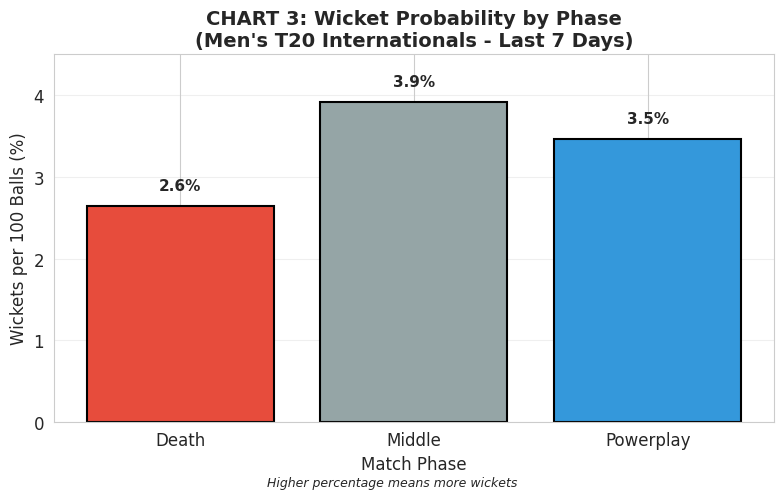

✅ Chart 3 saved as 'chart3_wicket_probability.png'


In [25]:
# CELL 8: CHART 3 - Wicket Probability
# =====================================

plt.figure(figsize=(8, 5))

# Calculate wicket rate (wickets per 100 balls)
wicket_rate = over_stats.groupby('phase')['wickets_in_over'].mean() * 100 / 6

# Colors for each phase
colors = {'Powerplay': '#3498db', 'Middle': '#95a5a6', 'Death': '#e74c3c'}
bar_colors = [colors[phase] for phase in wicket_rate.index]

# Create bar chart
bars = plt.bar(wicket_rate.index, wicket_rate.values,
               color=bar_colors, edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{height:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.title('CHART 3: Wicket Probability by Phase\n(Men\'s T20 Internationals - Last 7 Days)',
          fontsize=14, fontweight='bold')
plt.xlabel('Match Phase', fontsize=12)
plt.ylabel('Wickets per 100 Balls (%)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, max(wicket_rate.values) * 1.15)

# Add note
plt.figtext(0.5, 0.01, 'Higher percentage means more wickets',
            ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('chart3_wicket_probability.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved as 'chart3_wicket_probability.png'")


🤖 Training Machine Learning Models...
Training overs: 2261
Testing overs: 970

Linear Regression:
   MAE: 2.71 runs
   R² Score: 0.025

Random Forest:
   MAE: 2.85 runs
   R² Score: -0.051

Gradient Boosting:
   MAE: 2.75 runs
   R² Score: 0.013


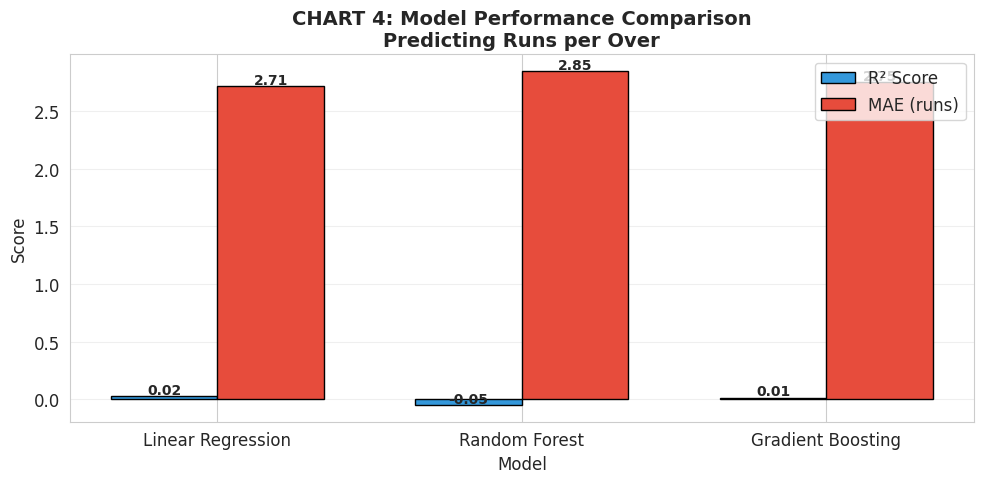


📊 Model Performance Summary:
                     MAE     R2
Linear Regression  2.714  0.025
Random Forest      2.848 -0.051
Gradient Boosting  2.753  0.013
✅ Model results saved to 'model_results.csv'


In [26]:
# CELL 9: CHART 4 - ML Model Performance
# =======================================

print("\n🤖 Training Machine Learning Models...")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Prepare features (like the example on Page 4)
# Use over number, phase, and wickets as predictors
X = pd.get_dummies(over_stats[['over_number', 'wickets_in_over', 'phase']],
                   columns=['phase'], prefix=['phase'])
y = over_stats['runs_in_over']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training overs: {len(X_train)}")
print(f"Testing overs: {len(X_test)}")

# Train models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    print(f"\n{name}:")
    print(f"   MAE: {results[name]['MAE']:.2f} runs")
    print(f"   R² Score: {results[name]['R2']:.3f}")

# Create comparison chart
plt.figure(figsize=(10, 5))

models_list = list(results.keys())
mae_scores = [results[m]['MAE'] for m in models_list]
r2_scores = [results[m]['R2'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

# Create bars
bars1 = plt.bar(x - width/2, r2_scores, width, label='R² Score',
                color='#3498db', edgecolor='black')
bars2 = plt.bar(x + width/2, mae_scores, width, label='MAE (runs)',
                color='#e74c3c', edgecolor='black')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('CHART 4: Model Performance Comparison\nPredicting Runs per Over',
          fontsize=14, fontweight='bold')
plt.xticks(x, models_list)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('chart4_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Create results table
results_df = pd.DataFrame(results).T.round(3)
print("\n📊 Model Performance Summary:")
print(results_df)

# Save results
results_df.to_csv('model_results.csv')
print("✅ Model results saved to 'model_results.csv'")

In [27]:
# CELL 10: Save everything to your computer
# ==========================================

print("💾 Saving all files...")

# Save DataFrames
df_balls.to_csv('mens_t20_ball_by_ball.csv', index=False)
over_stats.to_csv('mens_t20_over_stats.csv', index=False)

# Download all files
from google.colab import files

files_to_download = [
    'table1_phase_stats.png',
    'chart1_powerplay_vs_death.png',
    'chart2_smile_curve.png',
    'chart3_wicket_probability.png',
    'chart4_model_performance.png',
    'mens_t20_ball_by_ball.csv',
    'mens_t20_over_stats.csv',
    'model_results.csv'
]

print("\n📥 Downloading files...")
for file in files_to_download:
    try:
        files.download(file)
        print(f"✅ Downloaded: {file}")
    except:
        print(f"⚠️ Could not find: {file}")

print("\n🎯 DONE! All files saved to your computer.")
print("You can now close Colab and work on your report.")

💾 Saving all files...

📥 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: table1_phase_stats.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: mens_t20_over_stats.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: model_results.csv

🎯 DONE! All files saved to your computer.
You can now close Colab and work on your report.
